In [1]:
# ==========================================
# Fashion MNIST Classification using CNN
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Train-Test Split and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical

I0000 00:00:1778271448.952343   50368 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778271448.953309   50368 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778271449.257486   50368 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778271450.435012   50368 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:

# ==========================================
# 1. Load Dataset
# ==========================================

# Load training and testing datasets
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

# Display first 5 rows
print(train_df.head())


   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         

In [3]:
# ==========================================
# 2. Separate Features and Labels
# ==========================================

# First column = label
y_train = train_df.iloc[:, 0]
X_train = train_df.iloc[:, 1:]

y_test = test_df.iloc[:, 0]
X_test = test_df.iloc[:, 1:]


In [4]:
# ==========================================
# 3. Normalize Pixel Values
# ==========================================

# Pixel values range from 0-255
# Convert them into 0-1 range

X_train = X_train / 255.0
X_test = X_test / 255.0

# ========================

In [5]:
# ==========================================
# 4. Reshape Images
# ==========================================

# CNN expects image format:
# (samples, height, width, channels)

X_train = X_train.values.reshape(-1, 28, 28, 1)
X_test = X_test.values.reshape(-1, 28, 28, 1)


In [6]:
# ==========================================
# 5. One-Hot Encode Labels
# ==========================================

# Convert labels into categorical format

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [7]:
# ==========================================
# 6. Define Class Names
# ==========================================

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


In [9]:
# ==========================================
# 7. Build CNN Model
# ==========================================

model = Sequential()

# First Convolution Layer
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

# Max Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(10, activation='softmax'))

In [10]:
# ==========================================
# 8. Compile Model
# ==========================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================

In [11]:
# ==========================================
# 9. Train Model
# ==========================================

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.7974 - loss: 0.5602 - val_accuracy: 0.8693 - val_loss: 0.3704
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8664 - loss: 0.3690 - val_accuracy: 0.8842 - val_loss: 0.3222
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8834 - loss: 0.3231 - val_accuracy: 0.8973 - val_loss: 0.2870
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8944 - loss: 0.2898 - val_accuracy: 0.9007 - val_loss: 0.2733
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9036 - loss: 0.2641 - val_accuracy: 0.9052 - val_loss: 0.2630


In [12]:
# ==========================================
# 10. Evaluate Model
# ==========================================

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9072 - loss: 0.2508

Test Accuracy: 0.9071999788284302


In [13]:
# ==========================================
# 11. Predictions
# ==========================================

y_pred = model.predict(X_test)

# Convert probabilities into class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot test labels back
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [14]:
# ==========================================
# 12. Classification Report
# ==========================================

print("\nClassification Report:\n")

print(classification_report(y_true, y_pred_classes))


Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.93      0.85      1000
           1       0.99      0.98      0.99      1000
           2       0.86      0.88      0.87      1000
           3       0.92      0.92      0.92      1000
           4       0.88      0.84      0.86      1000
           5       0.99      0.97      0.98      1000
           6       0.80      0.63      0.70      1000
           7       0.95      0.95      0.95      1000
           8       0.97      0.99      0.98      1000
           9       0.95      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



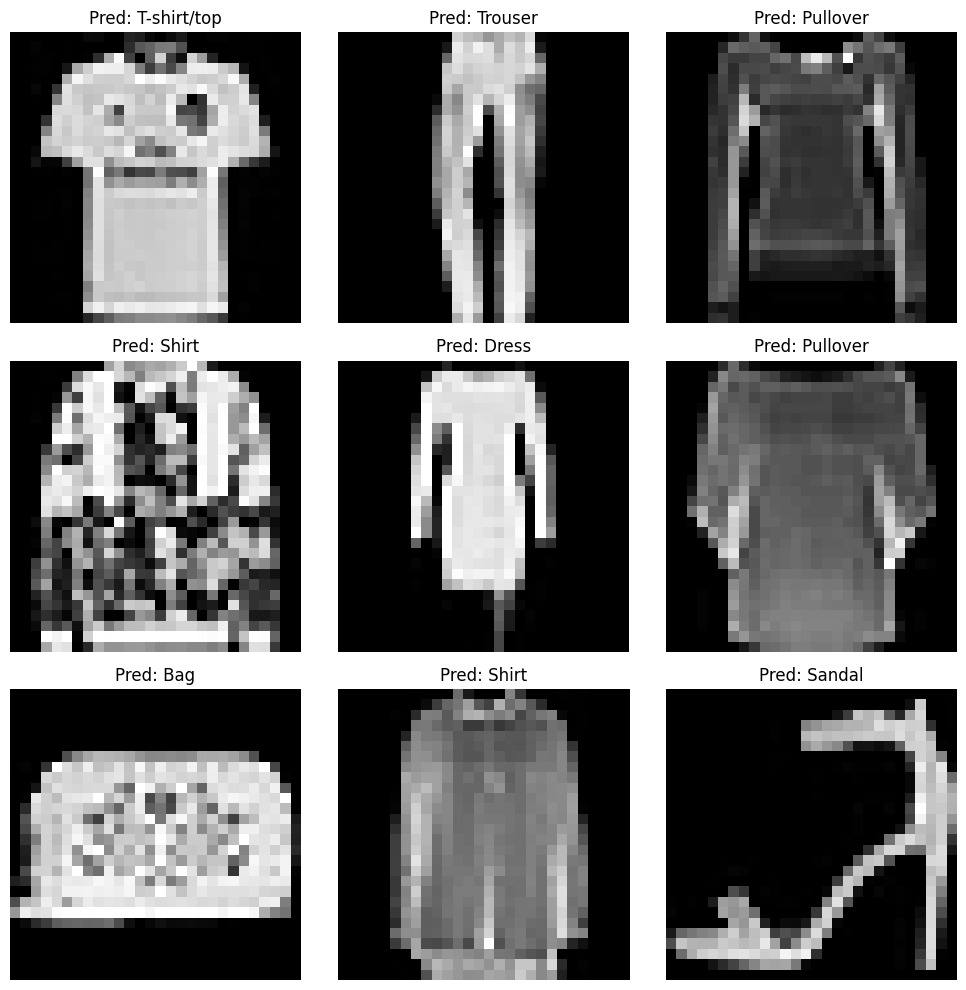

In [15]:
# ==========================================
# 13. Display Sample Predictions
# ==========================================

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    plt.title(
        "Pred: " + class_names[y_pred_classes[i]]
    )

    plt.axis('off')

plt.tight_layout()
plt.show()